In [6]:
import pandas as pd

train_tx = pd.read_csv("data/ieee-fraud-detection/train_transaction.csv")
train_id = pd.read_csv("data/ieee-fraud-detection/train_identity.csv")

print(train_tx.head())
print(train_id.head())
train_tx.head()


   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ... V330  V331  V332  V333  V334 V335  \
0    NaN  150.0    discover  142.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
1  404.0  150.0  mastercard  102.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
2  490.0  150.0        visa  166.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
3  567.0  150.0  mastercard  117.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
4  514.0  150.0  mastercard  102.0  ...  0.0   0.0   0.0   0.0   0.0  0.0   

  V336  V337  V338  V339  
0  NaN   NaN   NaN   NaN  
1  NaN   NaN   NaN  

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
print(train_tx.shape)
print(train_id.shape)

(590540, 394)
(144233, 41)


In [8]:
train_tx["isFraud"].value_counts(normalize=True)


isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

In [9]:
train_tx.isnull().mean().sort_values(ascending=False).head(20)

dist2    0.936284
D7       0.934099
D13      0.895093
D14      0.894695
D12      0.890410
D6       0.876068
D9       0.873123
D8       0.873123
V153     0.861237
V149     0.861237
V141     0.861237
V146     0.861237
V154     0.861237
V162     0.861237
V142     0.861237
V158     0.861237
V161     0.861237
V157     0.861237
V138     0.861237
V139     0.861237
dtype: float64

In [10]:
merged = train_tx.merge(train_id, on="TransactionID", how="left")
print(merged.shape)
print(train_tx["TransactionID"].isin(train_id["TransactionID"]).sum())


(590540, 434)
144233


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [12]:
merged.groupby("ProductCD")["isFraud"].mean().sort_values(ascending=False)

ProductCD
C    0.116873
S    0.058996
H    0.047662
R    0.037826
W    0.020399
Name: isFraud, dtype: float64

In [13]:
merged.groupby("card4")["isFraud"].mean().sort_values(ascending=False)

card4
discover            0.077282
visa                0.034756
mastercard          0.034331
american express    0.028698
Name: isFraud, dtype: float64

In [14]:
merged.groupby("card6")["isFraud"].mean().sort_values(ascending=False)

card6
credit             0.066785
debit              0.024263
charge card        0.000000
debit or credit    0.000000
Name: isFraud, dtype: float64

In [15]:
merged.groupby("DeviceType")["isFraud"].mean().sort_values(ascending=False)

DeviceType
mobile     0.101662
desktop    0.065215
Name: isFraud, dtype: float64

In [16]:
merged["has_identity"] = merged["TransactionID"].isin(train_id["TransactionID"])
merged.groupby("has_identity")["isFraud"].mean()

C:\Users\Siddhu\AppData\Local\Temp\ipykernel_9896\3260131175.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged["has_identity"] = merged["TransactionID"].isin(train_id["TransactionID"])


has_identity
False    0.020939
True     0.078470
Name: isFraud, dtype: float64

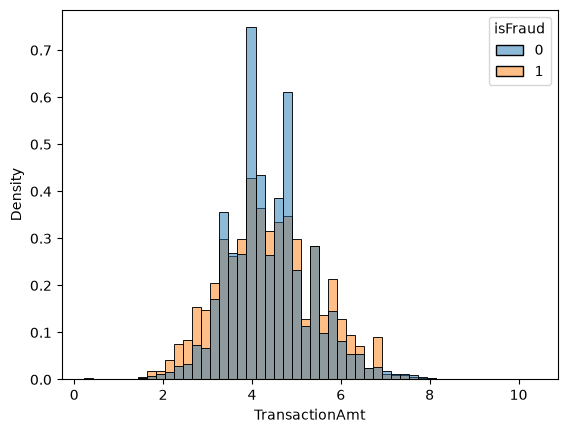

In [17]:
sns.histplot(data=merged, x=np.log1p(merged["TransactionAmt"]), hue="isFraud", stat="density", common_norm=False, bins=50)
plt.show()

C:\Users\Siddhu\AppData\Local\Temp\ipykernel_9896\2476673619.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged["hour"] = (merged["TransactionDT"] // 3600) % 24


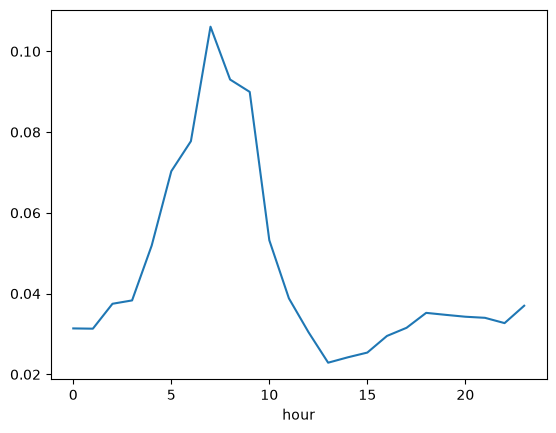

In [18]:
merged["hour"] = (merged["TransactionDT"] // 3600) % 24
merged.groupby("hour")["isFraud"].mean().plot()
plt.show()

In [19]:
missing = merged.isnull().mean()
print((missing > 0.5).sum(), (missing > 0.9).sum())
print(missing.sort_values(ascending=False).head(20))

214 12
id_24    0.991962
id_25    0.991310
id_08    0.991271
id_07    0.991271
id_21    0.991264
id_26    0.991257
id_22    0.991247
id_27    0.991247
id_23    0.991247
dist2    0.936284
D7       0.934099
id_18    0.923607
D13      0.895093
D14      0.894695
D12      0.890410
id_03    0.887689
id_04    0.887689
D6       0.876068
id_33    0.875895
D9       0.873123
dtype: float64


In [ ]:
#the 3.5% baseline, ProductCD C at 11.7% vs W at 2.0%, has_identity 7.8% vs 2.1%, mobile above the identity baseline, and 214 columns more than 50% missing.